#**AUDIT STATISTIK KAMPANYE PEMASARAN AKHIR TAHUN 2023**

**Objective:**
Menilai efektivitas dua jenis promosi (Diskon 20% vs Cashback Rp50.000) secara statistik, serta menganalisis pengaruh Ad Spend terhadap Traffic guna mendukung keputusan alokasi anggaran pemasaran yang lebih optimal.

**Metodologi:**
1. Data Understanding
2. Data Preparation
3. A/B Testing (Independent T-Test) pada Promo_Active.
4. Linear Regression Analysis pada Daily_Ad_Spend vs Website_Traffic.

**Kelompok 13**
*   Shofia Nabila
*   M Bintang Hikmattulloh


# Import Library Analitik dan Visualisasi Standar

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
import  statsmodels.api as sm

# Konfigurasi Parameter Visualisasi

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

# Inisialisasi Dataset

In [ ]:
df = pd.read_csv('/content/marketing_campaign_for_vinix (1).csv')

display(df.head())
display(df.info())

,Tanggal,Region_Code,Promo_Active,Daily_Ad_Spend,Website_Traffic,Daily_Revenue
0,2023-09-20,JABODETABEK,CASHBACK 50K,2162246.0,7600,Rp 49.362.908
1,2023-12-16,SULAWESI,cashback 50k,2724843.0,2970,Rp 19.980.313
2,2023-08-26,JABODETABEK,DISKON 20%,1186002.0,5667,Rp 75.667.735
3,2023-12-16,JAWA TIMUR,DISKON 20%,2079296.0,6108,Rp 74.303.388
4,2023-11-08,JABODETABEK,cashback 50k,2418979.0,8052,Rp 62.127.957


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1104 entries, 0 to 1103
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Tanggal          1104 non-null   object 
 1   Region_Code      1104 non-null   object 
 2   Promo_Active     1104 non-null   object 
 3   Daily_Ad_Spend   1060 non-null   float64
 4   Website_Traffic  1104 non-null   int64  
 5   Daily_Revenue    1104 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 51.9+ KB


None

# Data Inspection & Profiling

In [ ]:
# Inspeksi nilai unik pada kolom kategorikal
print("Nilai unik pada kolom Promo_Active (Sebelum Cleaning):")
print(df['Promo_Active'].unique())


Nilai unik pada kolom Promo_Active (Sebelum Cleaning):
[' CASHBACK 50K ' 'cashback 50k' ' DISKON 20% ' 'Diskon 20%' 'Diskon 20 %'
 'diskon 20%' 'Diskon-20%' 'CB 50K' 'Cashback 50K' 'Cashback 50k']


In [ ]:
# Eksplorasi data
df.describe()

,Daily_Ad_Spend,Website_Traffic
count,1.060000e+03,1104.000000
mean,2.713631e+06,6860.110507
std,1.328340e+06,9510.535388
min,5.052030e+05,1143.000000
25%,1.540663e+06,3564.500000
50%,2.648995e+06,5360.000000
75%,3.868024e+06,7657.250000
max,4.992336e+06,131833.000000


# Data Standardization

In [ ]:
# Standarisasi Kolom Kategorikal (Promo Active)
df['Promo_Active'] = df['Promo_Active'].str.lower().str.strip()
df['Promo_Active'] = df['Promo_Active'].replace('cb 50k', 'cashback 50k')
df['Promo_Active'] = df['Promo_Active'].replace('diskon-20%', 'diskon 20%')
df['Promo_Active'] = df['Promo_Active'].replace('diskon 20 %', 'diskon 20%')

print(df['Promo_Active'].unique())

['cashback 50k' 'diskon 20%']


In [ ]:
# Standarisasi Kolom Numerik (Daily_Reveneu)
# Ekstraksi karakter non-numerik (Rp, titik pemisah ribuan)
df['Daily_Revenue'] = df['Daily_Revenue'].str.replace('Rp', '')
df['Daily_Revenue'] = df['Daily_Revenue'].str.replace('.', '')

# Konversi vektor tipe data ke numerik
df['Daily_Revenue'] = df['Daily_Revenue'].astype(float)

display(df[['Daily_Revenue']].describe().T)


,count,mean,std,min,25%,50%,75%,max
Daily_Revenue,1104.0,5.581878e+07,3.460507e+07,170862.0,30781254.5,47324485.0,74288997.75,227393918.0


In [ ]:
# Handling missing valeu pada kolom (Daily_Ad_Spend)
df = df.dropna(subset=['Daily_Ad_Spend'])

# Outlier Detection
Pembersihan outlier harus disesuaikan dengan tujuan analisis.
Untuk uji perbedaan (t-test), cleaning dilakukan per kelompok.
Sedangkan untuk regresi, cleaning dilakukan berdasarkan variabel yang dianalisis agar hubungan antar variabel tidak terdistorsi.

In [ ]:
# Pembersihan dataset untuk uji t-test

df_ttest = df.copy()

for promo in df_ttest['Promo_Active'].unique():
    subset = df_ttest[df_ttest['Promo_Active'] == promo]

    Q1 = subset['Daily_Revenue'].quantile(0.25)
    Q3 = subset['Daily_Revenue'].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    subset = subset[(subset['Daily_Revenue'] >= lower) &
                    (subset['Daily_Revenue'] <= upper)]

    df_ttest = pd.concat([df_ttest[df_ttest['Promo_Active'] != promo], subset])

In [ ]:
# menghapus outlier untuk dataset regresi
df_reg = df.copy()

for col in ['Daily_Ad_Spend', 'Website_Traffic']:
    Q1 = df_reg[col].quantile(0.25)
    Q3 = df_reg[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_reg = df_reg[(df_reg[col] >= lower) &
                    (df_reg[col] <= upper)]

In [ ]:
iqr_summary = {}

for col in ['Daily_Ad_Spend', 'Website_Traffic']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    iqr_summary[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower,
        'Upper Bound': upper
    }

# ubah jadi DataFrame biar rapi
iqr_table = pd.DataFrame(iqr_summary).T
print(iqr_table)

                         Q1          Q3        IQR  Lower Bound  Upper Bound
Daily_Ad_Spend   1540663.00  3868023.50  2327360.5  -1950377.75   7359064.25
Website_Traffic     3573.75     7679.75     4106.0     -2585.25     13838.75


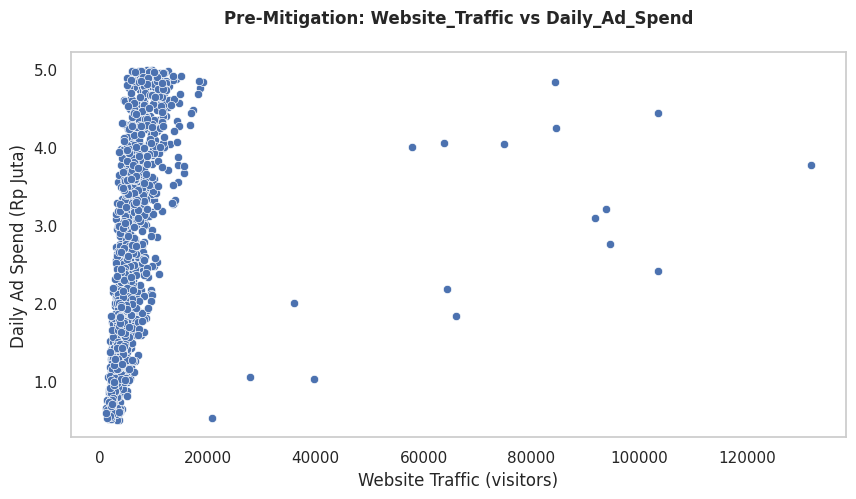

In [ ]:
# Diagnostik visual: Identifikasi anomali sebaran data
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Website_Traffic', y='Daily_Ad_Spend')
plt.title('Pre-Mitigation: Website_Traffic vs Daily_Ad_Spend\n', fontweight='bold')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}'))
plt.xlabel('Website Traffic (visitors)')
plt.ylabel('Daily Ad Spend (Rp Juta)')
plt.grid(False)

plt.show()

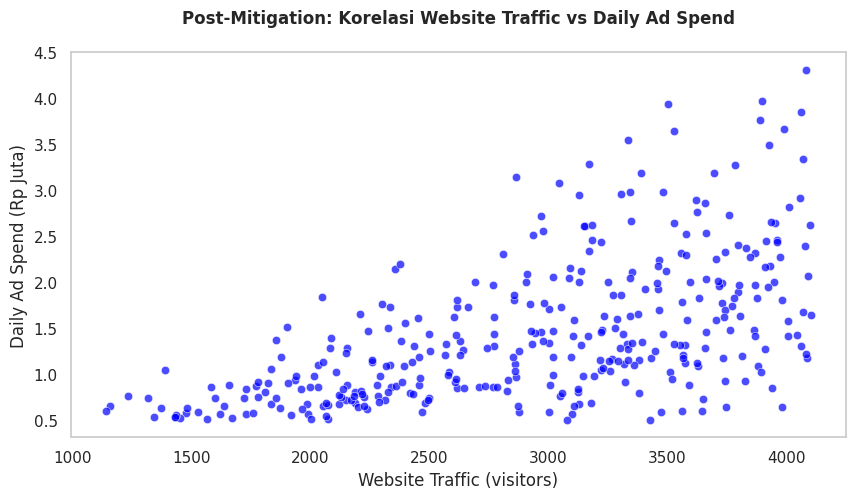

In [ ]:
# visualisasi setelah penghapusan outlier
df_reg = df[df['Website_Traffic'] < 4106.0].copy()

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_reg, x='Website_Traffic', y='Daily_Ad_Spend', alpha=0.7, color='blue')
plt.title("Post-Mitigation: Korelasi Website Traffic vs Daily Ad Spend\n", fontweight='bold')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}'))
plt.xlabel('Website Traffic (visitors)')
plt.ylabel('Daily Ad Spend (Rp Juta)')
plt.grid(False)
plt.show()


# Hypothesis Testing: Efektivitas Promosi

**Obejctive:** Menguji probabilitas signifikansi perbedaan rata-rata pendapatan antara promosi diskon dan cashback
*   H0 :  μDiskon=μCashback  (Tidak ada perbedaan signifikan).
* H1 :  μDiskon≠μCashback  (Terdapat perbedaan signifikan).
* Level Signifikansi ( α ): 0.05

--- Hasil Audit Statistik (Independent T-Test) ---
T-statistic: 14.3229
P-value: 0.000000

Kesimpulan: H0 ditolak. Terdapat perbedaan signifikan secara statistik pada daily revenue berdasarkan jenis promo.


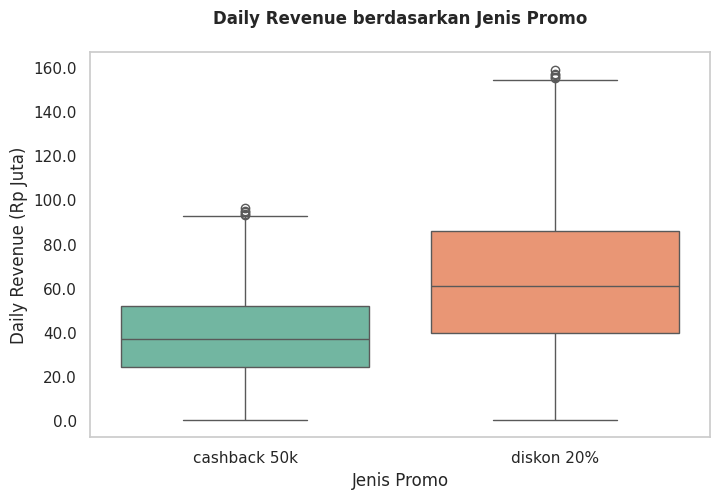

In [ ]:
# Pemisahan array populasi
diskon_20 = df_ttest[df_ttest['Promo_Active'] == 'diskon 20%']['Daily_Revenue']
cashback_50k = df_ttest[df_ttest['Promo_Active'] == 'cashback 50k']['Daily_Revenue']

# Eksekusi Independent T-Test (Asumsi variansi ekuivalen)
t_stat, p_value = stats.ttest_ind(diskon_20, cashback_50k, equal_var=True)

print("--- Hasil Audit Statistik (Independent T-Test) ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nKesimpulan: H0 ditolak. Terdapat perbedaan signifikan secara statistik pada daily revenue berdasarkan jenis promo.")
else:
    print("\nKesimpulan: H0 gagal ditolak. Tidak ada bukti statistik yang cukup atas perbedaan revenue.")


# Visualisasi Distribus
plt.figure(figsize=(8, 5))
sns.boxplot(x='Promo_Active', y='Daily_Revenue', data=df_ttest, palette='Set2')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}'))
plt.xlabel('Jenis Promo')
plt.ylabel('Daily Revenue (Rp Juta)')
plt.title('Daily Revenue berdasarkan Jenis Promo\n', fontweight='bold')
plt.grid(False)

plt.show()


# Predictive Modeling: OLS Regression

**Objective:** Membangun model Ordinary Leasts Squares (OLS) untuk mengukur kerfisien determinasi ($r^2$) dan proyektivitas `Client_Visit` terhadap `Daily_Ad_Spend`.

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           2115.8385     70.167     30.155      0.000    1977.836    2253.841
Daily_Ad_Spend     0.0006   4.25e-05     13.152      0.000       0.000       0.001

R-Squared Value: 0.3314


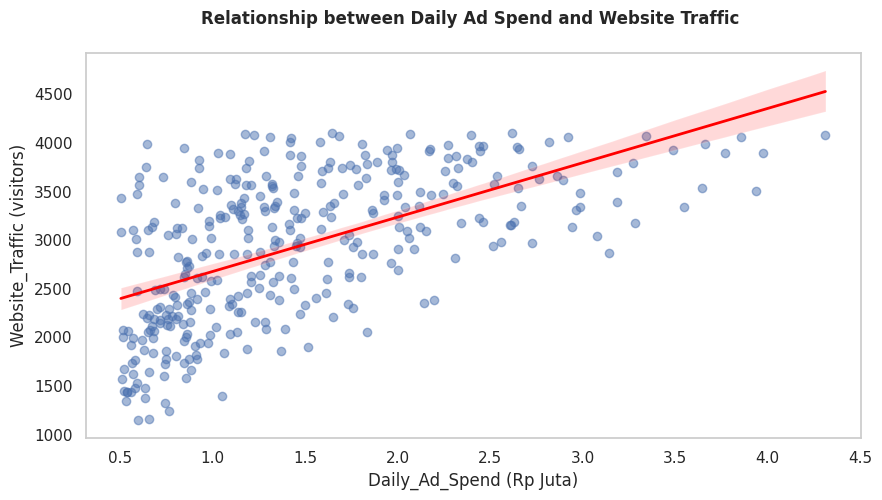

In [ ]:
X = df_reg[['Daily_Ad_Spend']]
Y = df_reg['Website_Traffic']

X_const = sm.add_constant(X)

ols_models = sm.OLS(Y, X_const).fit()

print(ols_models.summary().tables[1])
print(f"\nR-Squared Value: {ols_models.rsquared:.4f}")

#ekstraksi parameter garis lurus (y = mx + c)
intercept = ols_models.params['const']
slope = ols_models.params['Daily_Ad_Spend']

plt.figure(figsize=(10, 5))
sns.regplot(data=df_reg, x='Daily_Ad_Spend', y='Website_Traffic', scatter_kws={'alpha': 0.5}, line_kws={'color':'red', 'linewidth':2})
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}'))
plt.title('Relationship between Daily Ad Spend and Website Traffic \n', fontweight='bold')
plt.xlabel('Daily_Ad_Spend (Rp Juta)')
plt.ylabel('Website_Traffic (visitors)')
plt.grid(False)

plt.show()
